In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from helpers import *

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
DATASET_DIR = "../planetsdataset"

In [3]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

In [4]:
train_dataset, valid_dataset, test_dataset, class_names = load_datasets(DATASET_DIR, IMG_SIZE, BATCH_SIZE)

Found 2430 files belonging to 12 classes.
Found 666 files belonging to 12 classes.
Found 341 files belonging to 12 classes.


In [5]:
class_names

['asteroid',
 'earth',
 'galaxy',
 'jupiter',
 'mars',
 'mercury',
 'moon',
 'neptune',
 'pluto',
 'saturn',
 'uranus',
 'venus']

In [6]:
num_classes = len(class_names)

In [7]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.Rescaling(1.0 / 255),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 64, 64, 3)         0         
                                                                 
 flatten (Flatten)           (None, 12288)             0         
                                                                 
 dense (Dense)               (None, 128)               1572992   
                                                                 
 dense_1 (Dense)             (None, 12)                1548      
                                                                 
Total params: 1574540 (6.01 MB)
Trainable params: 1574540 (6.01 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [8]:
early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [9]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
55/76 [====================>.........] - ETA: 2s - loss: 2.4284 - accuracy: 0.3574

2026-04-19 20:52:23.040678: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: known incorrect sRGB profile


76/76 [==============================] - 11s 127ms/step - loss: 2.1709 - accuracy: 0.4095 - val_loss: 1.2930 - val_accuracy: 0.5721
Epoch 2/20
55/76 [====================>.........] - ETA: 2s - loss: 1.1555 - accuracy: 0.6392

2026-04-19 20:52:33.538821: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: known incorrect sRGB profile


76/76 [==============================] - 11s 132ms/step - loss: 1.1188 - accuracy: 0.6486 - val_loss: 1.0512 - val_accuracy: 0.6742
Epoch 3/20
55/76 [====================>.........] - ETA: 2s - loss: 0.9010 - accuracy: 0.7494

...

76/76 [==============================] - 9s 112ms/step - loss: 0.1815 - accuracy: 0.9519 - val_loss: 0.6966 - val_accuracy: 0.8619
Epoch 19/20
55/76 [====================>.........] - ETA: 2s - loss: 0.1527 - accuracy: 0.9614

2026-04-19 20:55:20.233929: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: known incorrect sRGB profile


76/76 [==============================] - 9s 112ms/step - loss: 0.1674 - accuracy: 0.9588 - val_loss: 0.6841 - val_accuracy: 0.8544
Epoch 20/20
55/76 [====================>.........] - ETA: 2s - loss: 0.1422 - accuracy: 0.9659

2026-04-19 20:55:29.643918: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: known incorrect sRGB profile


76/76 [==============================] - 9s 112ms/step - loss: 0.1451 - accuracy: 0.9654 - val_loss: 0.6538 - val_accuracy: 0.8589


In [10]:
test_loss, test_acc = model.evaluate(test_dataset)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

11/11 [==============================] - 1s 18ms/step - loss: 0.5647 - accuracy: 0.8622
Test loss: 0.5646674036979675
Test accuracy: 0.8621701002120972


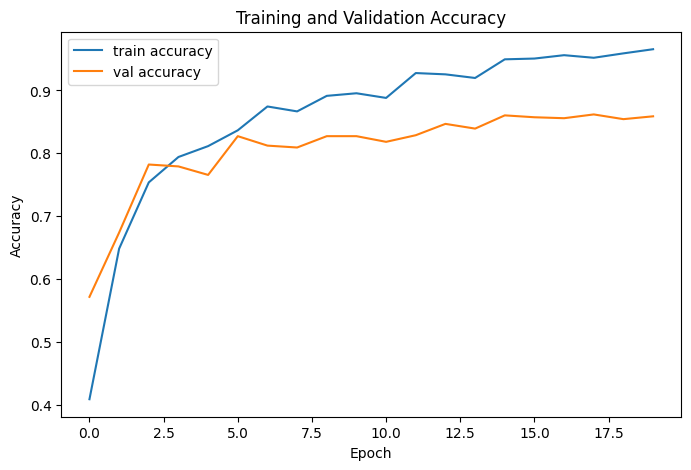

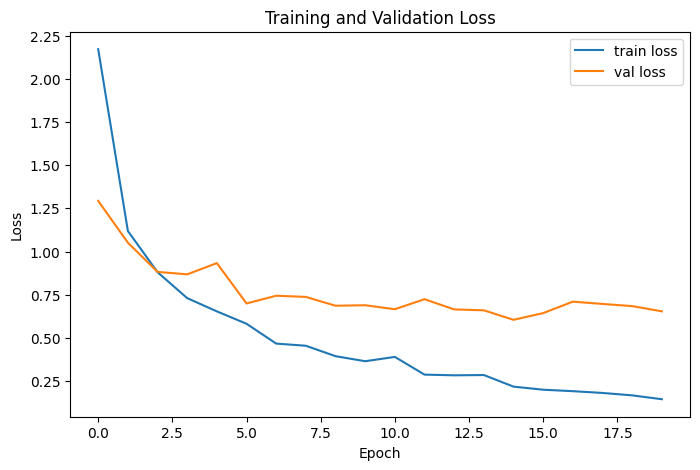

In [11]:
plot_history(history)

In [12]:
y_pred_probs = model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([y for x, y in test_dataset], axis=0)
cm = confusion_matrix(y_true, y_pred)

11/11 [==============================] - 1s 14ms/step


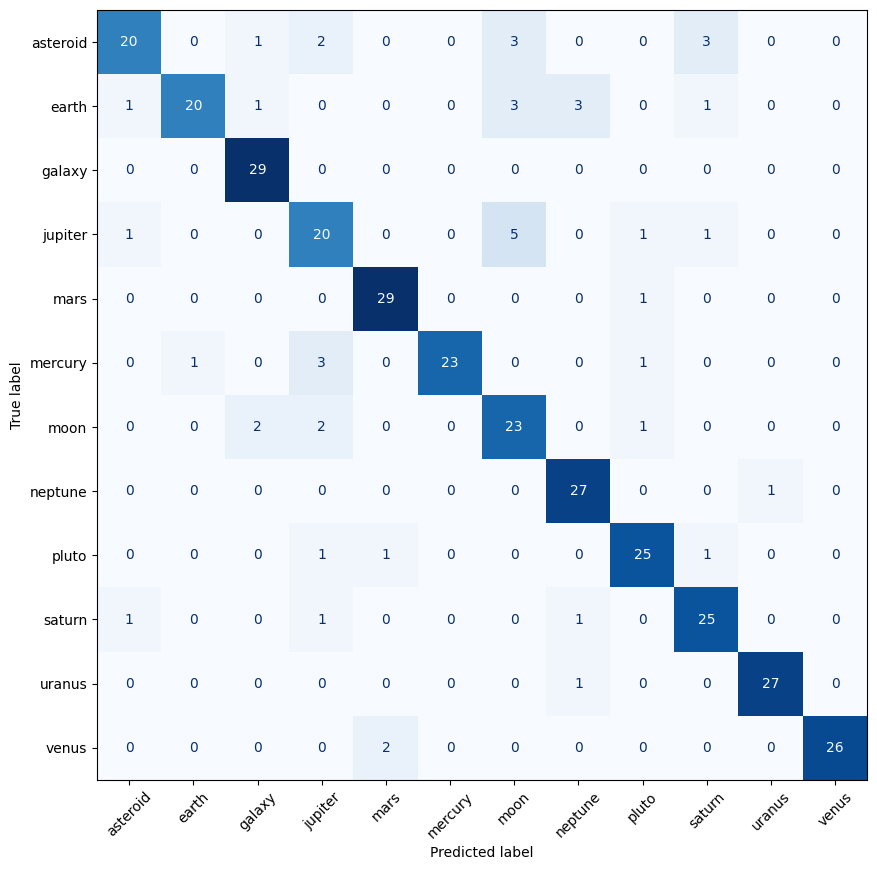

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.show()